In [34]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# open dataset
ds = xr.open_dataset("data/atlantic_sst.nc")

# inspect contents
print(ds)

<xarray.Dataset> Size: 10MB
Dimensions:  (time: 1516, lat: 31, lon: 51)
Coordinates:
  * time     (time) datetime64[ns] 12kB 1900-01-01 1900-02-01 ... 2026-04-01
  * lat      (lat) float32 124B 60.0 58.0 56.0 54.0 52.0 ... 8.0 6.0 4.0 2.0 0.0
  * lon      (lon) float32 204B 280.0 282.0 284.0 286.0 ... 376.0 378.0 380.0
Data variables:
    sst      (time, lat, lon) float32 10MB ...
Attributes: (12/39)
    climatology:               Climatology is based on 1971-2000 SST, Xue, Y....
    description:               In situ data: ICOADS2.5 before 2007 and NCEP i...
    keywords_vocabulary:       NASA Global Change Master Directory (GCMD) Sci...
    keywords:                  Earth Science > Oceans > Ocean Temperature > S...
    instrument:                Conventional thermometers
    source_comment:            SSTs were observed by conventional thermometer...
    ...                        ...
    comment:                   SSTs were observed by conventional thermometer...
    summary:      

In [35]:
sst = ds["sst"]

annual_sst = (
    sst
    .groupby("time.year")
    .mean(dim=["time", "lat", "lon"], skipna=True)
)

df = annual_sst.to_dataframe().reset_index()

df = df.rename(columns={
    "year": "year",
    "sst": "avg_sst"
})

df.head()

,year,avg_sst
0,1900,19.243366
1,1901,19.229940
2,1902,19.036846
3,1903,18.852930
4,1904,18.707611


In [36]:
df = df[df["year"] <=2025]
df.to_csv("data/atlantic_sst_annual.csv", index=False)

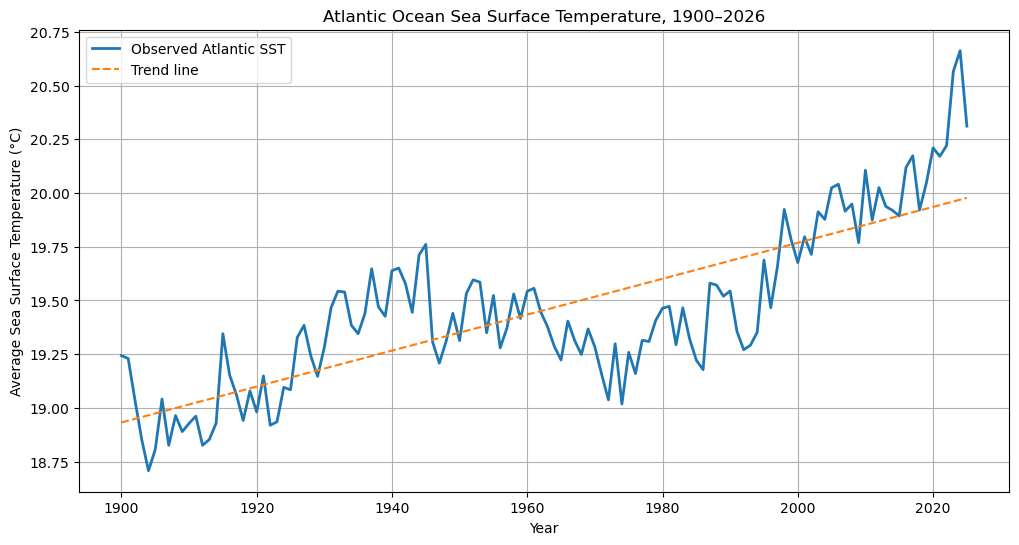

In [37]:
import matplotlib.pyplot as plt
import numpy as np

x = df["year"]
y = df["avg_sst"]

plt.figure(figsize=(12,6))
plt.plot(x, y, linewidth=2, label="Observed Atlantic SST")

z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.plot(x, p(x), linestyle="--", label="Trend line")

plt.xlabel("Year")
plt.ylabel("Average Sea Surface Temperature (°C)")
plt.title("Atlantic Ocean Sea Surface Temperature, 1900–2026")
plt.legend()
plt.grid(True)
plt.show()

In [47]:
import intake
import os

os.makedirs("data", exist_ok=True)

url = "https://storage.googleapis.com/cmip6/pangeo-cmip6.json"
col = intake.open_esm_datastore(url)

scenarios = ["ssp126", "ssp245", "ssp585"]

for scenario in scenarios:

    print(f"\nCurrently processing {scenario}")

    cat = col.search(
        experiment_id=scenario,
        table_id="Omon",
        variable_id="tos",
        member_id="r1i1p1f1",
        source_id="GFDL-ESM4"
    )

    dset_dict = cat.to_dataset_dict(
        zarr_kwargs={"consolidated": True},
        storage_options={"token": "anon"}
    )

    ds_cmip = list(dset_dict.values())[0]

    tos = ds_cmip["tos"].squeeze()

    lat = ds_cmip["lat"]
    lon = ds_cmip["lon"]

    lon_adjusted = xr.where(lon > 180, lon - 360, lon)

    atlantic_mask = (
        (lat >= 0) &
        (lat <= 60) &
        (lon_adjusted >= -80) &
        (lon_adjusted <= 20)
    )

    atlantic_cmip = tos.where(atlantic_mask)

    annual_cmip = (
        atlantic_cmip
        .groupby("time.year")
        .mean(dim=..., skipna=True)
    )

    df = annual_cmip.to_dataframe().reset_index()
    df = df.rename(columns={"tos": "projected_sst"})
    df = df[["year", "projected_sst"]].dropna()

    df = df[df["year"] >= 2026]

    df.to_csv(f"data/{scenario}.csv", index=False)

    print(f"{scenario}.csv saved")

print("\nAll scenarios saved")


Currently processing ssp126

--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


<div><progress max="2" value="2"></progress> 100.00% [2/2 00:00&lt;00:00]</div>

ssp126.csv saved

Currently processing ssp245

--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


<div><progress max="2" value="2"></progress> 100.00% [2/2 00:00&lt;00:00]</div>

ssp245.csv saved

Currently processing ssp585

--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


<div><progress max="2" value="2"></progress> 100.00% [2/2 00:00&lt;00:00]</div>

ssp585.csv saved

All scenarios saved


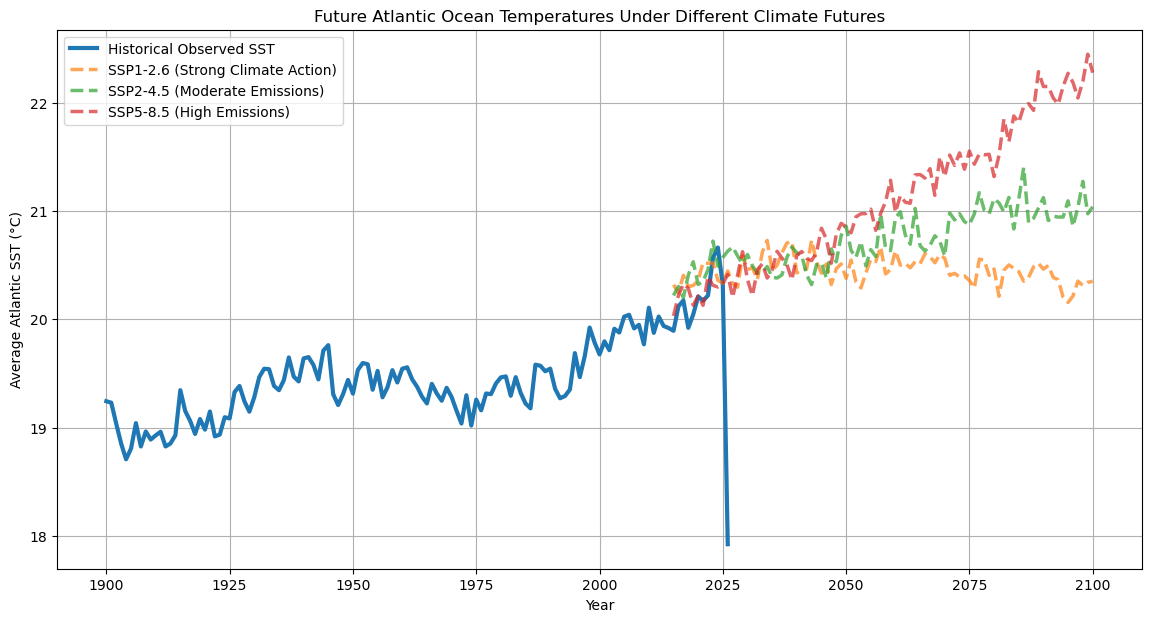

In [48]:
plt.figure(figsize=(14,7))

# historical SST
plt.plot(
    noaa_df["year"],
    noaa_df["avg_sst"],
    linewidth=3,
    label="Historical Observed SST"
)

# SSP1-2.6
plt.plot(
    ssp126["year"],
    ssp126["projected_sst"],
    linestyle="--",
    linewidth=2.5,
    alpha=0.7,
    label="SSP1-2.6 (Strong Climate Action)"
)

# SSP2-4.5
plt.plot(
    ssp245["year"],
    ssp245["projected_sst"],
    linestyle="--",
    linewidth=2.5,
    alpha=0.7,
    label="SSP2-4.5 (Moderate Emissions)"
)

# SSP5-8.5
plt.plot(
    ssp585["year"],
    ssp585["projected_sst"],
    linestyle="--",
    linewidth=2.5,
    alpha=0.7,
    label="SSP5-8.5 (High Emissions)"
)

plt.xlabel("Year")
plt.ylabel("Average Atlantic SST (°C)")
plt.title("Future Atlantic Ocean Temperatures Under Different Climate Futures")

plt.legend()
plt.grid(True)

plt.show()